# 04 · Model experiments and interpretation

Run `python -m src.models.train --with-shap` first. This notebook reads executed experiment artifacts; it does not tune models on test outcomes. Average precision is reported as PR-AUC/AP throughout, not trapezoidal PR area.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
from src.config import FIGURES_DIR, METRICS_DIR, FEATURE_COLUMNS
from src.data.load_data import load_data, split_data
from src.data.explore import exploration_tables
data = load_data()
X_train, X_test, y_train, y_test = split_data(data)

report = json.loads((METRICS_DIR / 'model_metrics.json').read_text(encoding='utf-8'))
display(Markdown((ROOT / 'reports/results.md').read_text(encoding='utf-8')))

# Executed experiment results

| Model | CV AP (mean ± SD) | Test AP | Test ROC-AUC | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| dummy | 0.162 ± 0.000 | 0.160 | 0.500 | 0.000 | 0.000 | 0.000 |
| logistic_regression | 0.651 ± 0.061 | 0.584 | 0.812 | 0.615 | 0.340 | 0.438 |
| logistic_balanced | 0.606 ± 0.082 | 0.561 | 0.803 | 0.349 | 0.638 | 0.451 |
| random_forest | 0.552 ± 0.058 | 0.436 | 0.789 | 0.524 | 0.468 | 0.494 |
| hist_gradient_boosting | 0.604 ± 0.045 | 0.542 | 0.796 | 0.786 | 0.234 | 0.361 |

Table classification metrics use threshold 0.50. AP is average precision, not trapezoidal PR area.

Selected **logistic_regression** at threshold **0.20**, chosen by maximum F2 on training out-of-fold predictions.

At the frozen operating threshold, holdout AP = **0.584**, ROC-AUC = **0.812**, precision = **0.423**, recall = **0.638**, F1 = **0.508**.

- True positives: 30 observed attrition cases flagged.
- True negatives: 206 observed retention cases not flagged.
- False positives: 41 observed retention cases flagged.
- False negatives: 17 observed attrition cases missed.

Selection uses only five-fold training average precision. Prefer unweighted, then balanced logistic regression when within 0.01 AP of the best non-dummy model, for interpretability and simpler operation. Otherwise use the highest mean AP. Best AP candidate: logistic_regression; selected: logistic_regression. This rule was fixed before holdout evaluation.

OOF threshold scores reuse the training folds used for model comparison and are selection diagnostics, not an unbiased performance estimate. The holdout is evaluated after choices are frozen. There are 47 positive holdout examples, so small count changes materially affect recall.


## Stratified five-fold comparison

Compare mean and population SD for AP, ROC-AUC, precision, recall, and F1. Models were fixed in advance. The dummy prior predicts retention at 0.50; balanced logistic regression changes the tradeoff and may distort uncalibrated probabilities.

,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
dummy,0.500000,0.000000,0.161565,0.000274,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
logistic_regression,0.839189,0.028941,0.651440,0.061070,0.776350,0.074445,0.442105,0.096188,0.561011,0.097680
logistic_balanced,0.827286,0.028340,0.605828,0.081746,0.372076,0.037919,0.736842,0.062275,0.492471,0.033675
random_forest,0.795239,0.031042,0.551575,0.058223,0.597756,0.083346,0.421053,0.107863,0.484304,0.084648
hist_gradient_boosting,0.820008,0.031182,0.604145,0.044782,0.750943,0.059408,0.300000,0.061378,0.425298,0.066359
logistic_without_sensitive,0.837264,0.023445,0.632025,0.058153,0.733101,0.114680,0.421053,0.089628,0.534384,0.103176
logistic_reduced_correlations,0.838045,0.025978,0.646711,0.059031,0.768609,0.092811,0.431579,0.079123,0.549386,0.078442


Selection uses only five-fold training average precision. Prefer unweighted, then balanced logistic regression when within 0.01 AP of the best non-dummy model, for interpretability and simpler operation. Otherwise use the highest mean AP. Best AP candidate: logistic_regression; selected: logistic_regression. This rule was fixed before holdout evaluation.

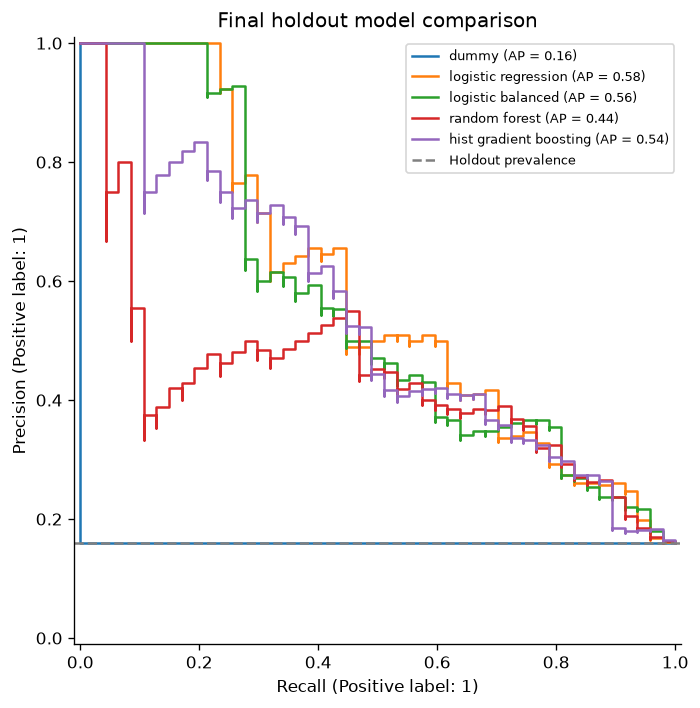

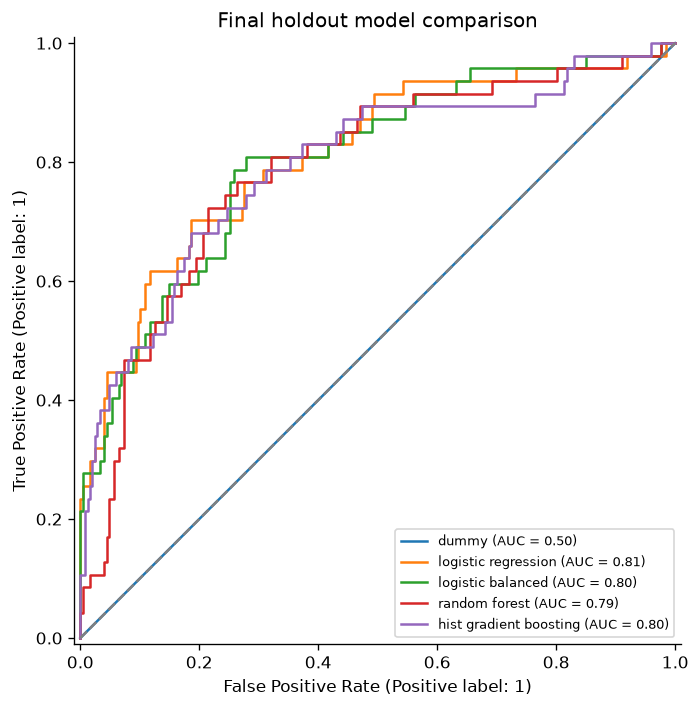

In [2]:
cv = pd.DataFrame({name: {f'{metric}_{stat}': value for metric, values in metrics.items()
    for stat, value in values.items()} for name, metrics in report['cross_validation'].items()}).T
display(cv)
display(Markdown(report['selection_reason']))
display(Image(filename=str(FIGURES_DIR / 'precision_recall_curve.png')))
display(Image(filename=str(FIGURES_DIR / 'roc_curve.png')))

## Threshold optimization and mistakes in business terms

The operating point maximizes F2 on out-of-fold training predictions, giving recall more weight than precision. This is an illustrative preference, not an estimate of business costs. Missing a potential support opportunity and contacting someone who would remain may have different costs; real deployment would need an agreed policy.

,roc_auc,pr_auc,precision,recall,f1,brier_score,threshold,true_negatives,false_positives,false_negatives,true_positives,n,positive_count,f2
0,0.837867,0.64821,0.254932,0.884211,0.395760,0.090376,0.05,495,491,22,168,1176,190,0.591966
1,0.837867,0.64821,0.326403,0.826316,0.467958,0.090376,0.10,662,324,33,157,1176,190,0.632554
2,0.837867,0.64821,0.362025,0.752632,0.488889,0.090376,0.15,734,252,47,143,1176,190,0.619048
3,0.837867,0.64821,0.428125,0.721053,0.537255,0.090376,0.20,803,183,53,137,1176,190,0.634259
4,0.837867,0.64821,0.474074,0.673684,0.556522,0.090376,0.25,844,142,62,128,1176,190,0.621359
5,0.837867,0.64821,0.537445,0.642105,0.585132,0.090376,0.30,881,105,68,122,1176,190,0.618034
6,0.837867,0.64821,0.620321,0.610526,0.615385,0.090376,0.35,915,71,74,116,1176,190,0.612460
7,0.837867,0.64821,0.675325,0.547368,0.604651,0.090376,0.40,936,50,86,104,1176,190,0.568928
8,0.837867,0.64821,0.726562,0.489474,0.584906,0.090376,0.45,951,35,97,93,1176,190,0.523649
9,0.837867,0.64821,0.785047,0.442105,0.565657,0.090376,0.50,963,23,106,84,1176,190,0.484429


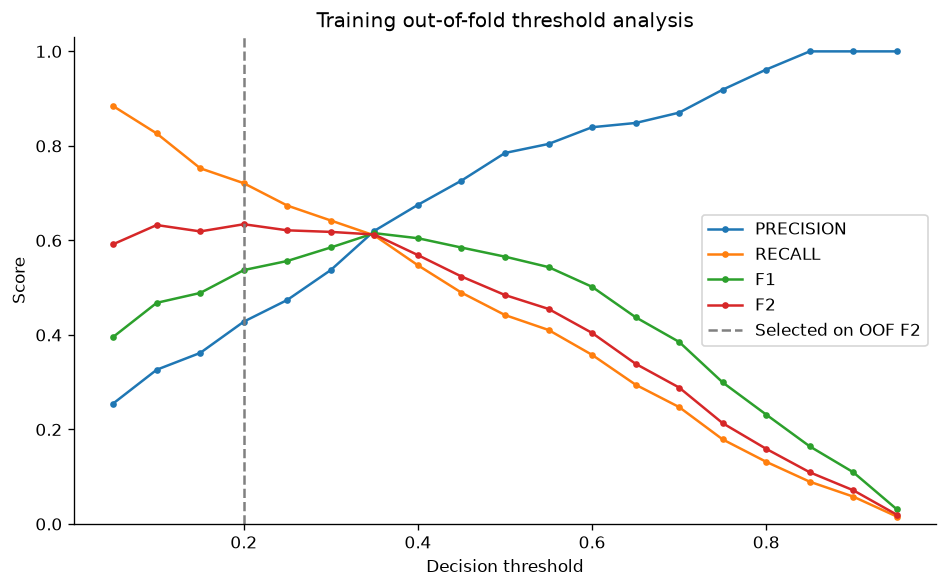

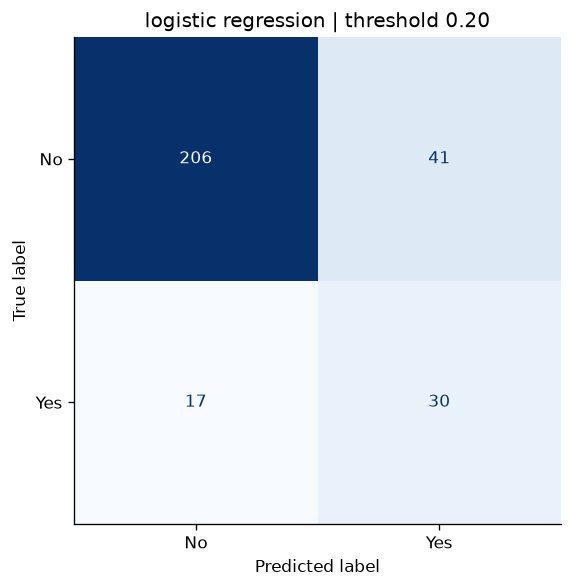

In [3]:
display(pd.read_csv(METRICS_DIR / 'threshold_analysis.csv'))
display(Image(filename=str(FIGURES_DIR / 'threshold_analysis.png')))
display(Image(filename=str(FIGURES_DIR / 'confusion_matrix.png')))

A true positive flags an observed attrition case; a false positive flags an observed retention case. A true negative leaves a retention case unflagged; a false negative misses an attrition case. The final holdout scores are the evaluation evidence. OOF scores reused in selection are optimistic diagnostics.

## Interpretable associations

Inspect positive and negative logistic coefficients plus original-feature permutation importance. Correlated predictors can divide or mask importance. Neither method identifies causes.

,feature,coefficient
0,JobRole_Laboratory Technician,1.030262
1,OverTime_Yes,0.916122
2,BusinessTravel_Travel_Frequently,0.898107
3,JobRole_Sales Representative,0.880280
4,EducationField_Human Resources,0.599713
5,YearsSinceLastPromotion,0.535576
6,NumCompaniesWorked,0.483406
7,MaritalStatus_Single,0.475509
8,EducationField_Technical Degree,0.409957
9,DistanceFromHome,0.383044


,feature,coefficient
41,YearsWithCurrManager,-0.391808
42,Age,-0.408286
43,JobSatisfaction,-0.412518
44,EnvironmentSatisfaction,-0.471657
45,TotalWorkingYears,-0.520362
46,JobRole_Healthcare Representative,-0.579318
47,EducationField_Other,-0.715120
48,BusinessTravel_Non-Travel,-0.916351
49,OverTime_No,-0.928796
50,JobRole_Research Director,-1.034146


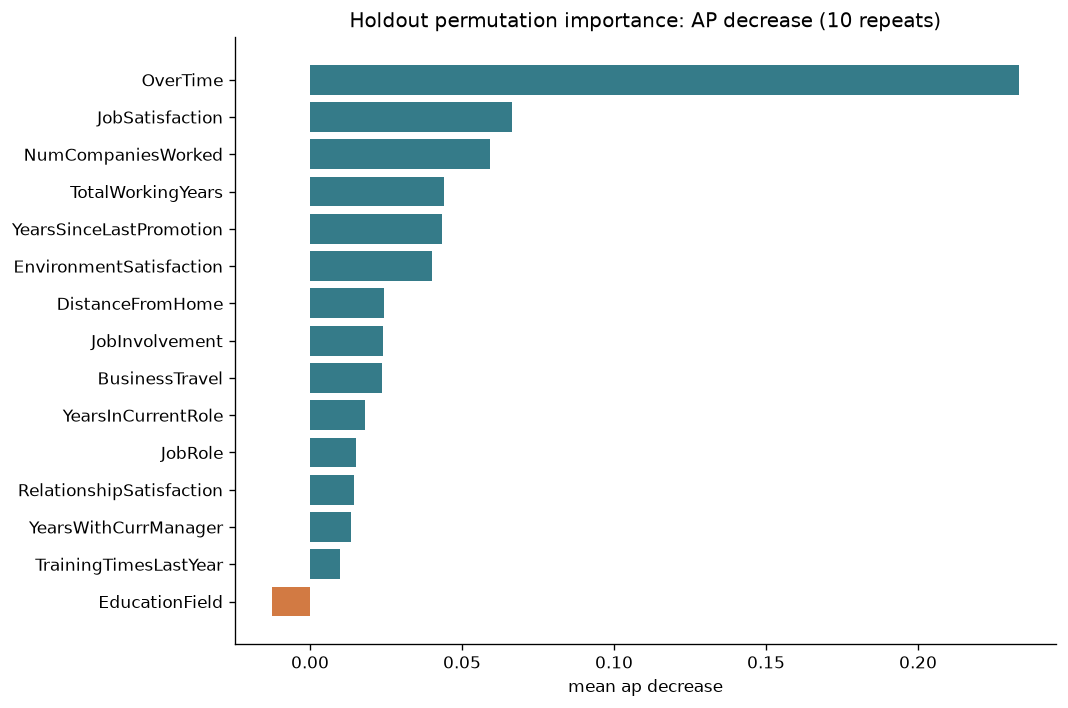

{'status': 'generated',
 'units': 'log-odds of Attrition=Yes',
 'rows': 60,
 'individual_holdout_position': 0,
 'individual_base_value': -2.321987072933257,
 'individual_model_probability': 0.0770764240558973}

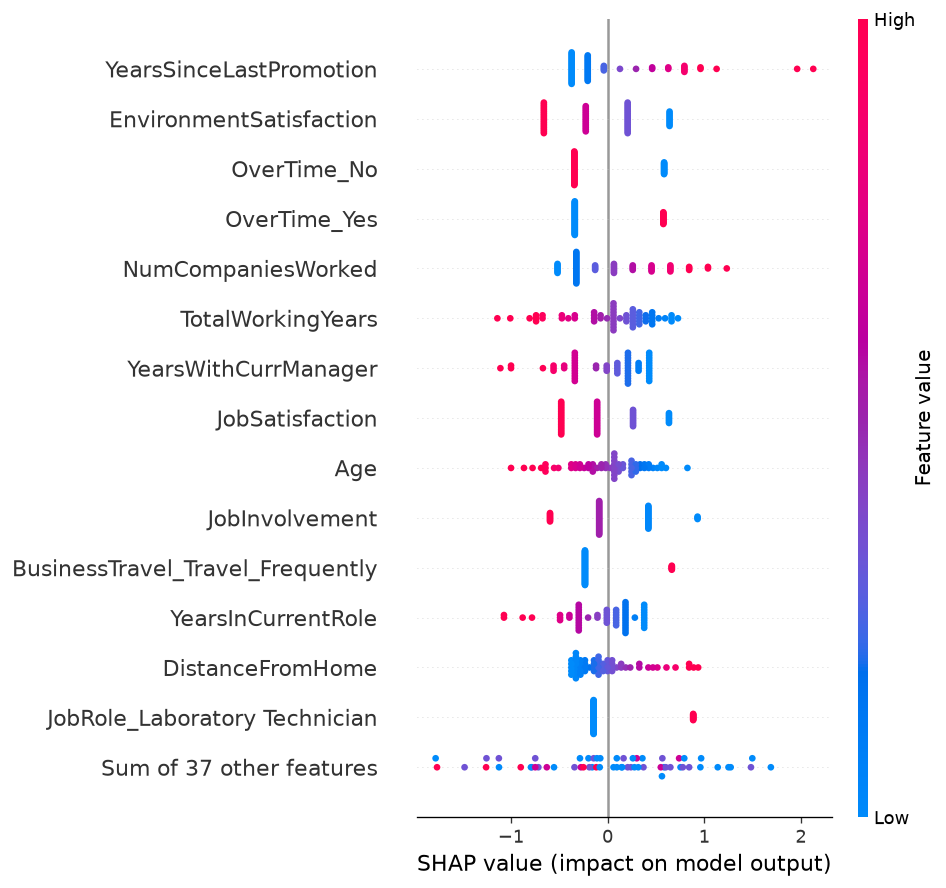

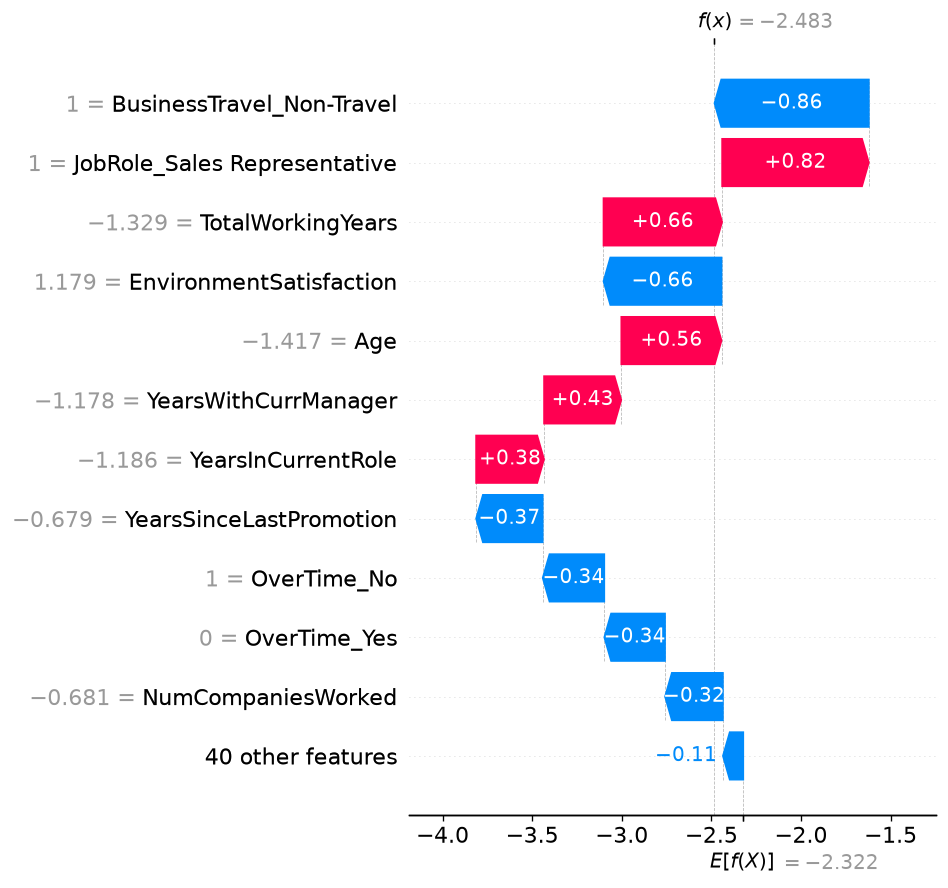

In [4]:
coefficients = pd.read_csv(METRICS_DIR / 'logistic_regression_coefficients.csv')
display(coefficients.head(10))
display(coefficients.tail(10))
display(Image(filename=str(FIGURES_DIR / 'feature_importance.png')))
display(report['shap'])
if report['shap']['status'] == 'generated':
    display(Image(filename=str(FIGURES_DIR / 'shap_summary.png')))
    display(Image(filename=str(FIGURES_DIR / 'shap_individual.png')))

## Responsible ML and ablations

Compare the same unweighted logistic model with/without Gender, Age, and MaritalStatus, and separately without three related career variables. These prespecified experiments are training-CV diagnostics, not a fairness guarantee or an extra test-selected model. The final model retains the sensitive attributes for this educational comparison.

In [5]:
display(report['sensitive_ablation'])
display(report['correlation_ablation'])
display(pd.read_csv(METRICS_DIR / 'subgroup_metrics.csv'))
display(Markdown(f"CV AP change after removing sensitive attributes: **{report['sensitive_ablation']['cv_ap_change']:+.3f}**. "
    f"CV AP change after removing the correlated subset: **{report['correlation_ablation']['cv_ap_change']:+.3f}**. "
    'Small differences must be considered alongside fold variability.'))

{'excluded': ['Gender', 'Age', 'MaritalStatus'],
 'cv_ap_change': -0.019414786632925285}

{'excluded': ['JobLevel', 'YearsInCurrentRole', 'YearsWithCurrManager'],
 'cv_ap_change': -0.004728759919792713}

,attribute,group,n,positive_count,recall,false_positive_rate,selection_rate,precision
0,Gender,Female,116,16,0.687500,0.200000,0.267241,0.354839
1,Gender,Male,178,31,0.612903,0.142857,0.224719,0.475000
2,MaritalStatus,Married,133,18,0.555556,0.130435,0.187970,0.400000
3,MaritalStatus,Divorced,64,4,1.000000,0.050000,0.109375,0.571429
4,MaritalStatus,Single,97,25,0.640000,0.319444,0.402062,0.410256
5,AgeBand,18-29,68,17,0.764706,0.254902,0.382353,0.500000
6,AgeBand,40-49,67,8,0.500000,0.101695,0.149254,0.400000
7,AgeBand,30-39,125,14,0.785714,0.189189,0.256000,0.343750
8,AgeBand,50+,34,8,0.250000,0.038462,0.088235,0.666667


CV AP change after removing sensitive attributes: **-0.019**. CV AP change after removing the correlated subset: **-0.005**. Small differences must be considered alongside fold variability.

## Key Findings

The executed results quantify how much each model improves over the dummy baseline. Threshold selection increases recall at the expense of false positives. Explanations describe model associations, and subgroup metrics remain uncertain because denominators are small. The fictional, cross-sectional sample does not validate a real employment decision system.

## Next Steps

Investigate calibration with independent validation, repeated/nested CV, temporal generalization, formal fairness assessment, and support-oriented human oversight. This project must not be used as an automated system for firing, promotion, hiring, disciplinary action, or other high-impact employment decisions.